In [ ]:
#import the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load the dataset
df = pd.read_csv('clean_data.csv')

#Understand the data
print('------First five rows of data------')
print(df.head())

print('\n-------------Shape of dataset-----------')
print(df.shape)

print('\n----------Information of dataset----------')
print(df.info())

print('\n----------Summary of dataset----------')
print(df.describe())

------First five rows of data------
    ID Customer_Name   Order_ID  Order_Date        Product     Category  \
0  100  Customer_100  ORD-41285  2024-11-22        Blender         Home   
1  101  Customer_101  ORD-35783  2025-07-05     Smartphone  Electronics   
2  102  Customer_102  ORD-84355  2024-12-23  Tennis racket       Sports   
3  103  Customer_103  ORD-57811  2025-03-19        Science        Books   
4  104  Customer_104  ORD-93614  2025-10-20      Biography        Books   

   Quantity   Price    Payment_Method      Status    Total  
0         3  465.42  Cash on Delivery     Shipped  1396.24  
1         2  560.99            PayPal  Processing  1121.97  
2         1  389.05            PayPal   Delivered   389.05  
3         5  233.92            PayPal  Processing  1169.60  
4         1  552.51  Cash on Delivery  Processing   552.51  

-------------Shape of dataset-----------
(101, 11)

----------Information of dataset----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1

**Univariate Analysis**

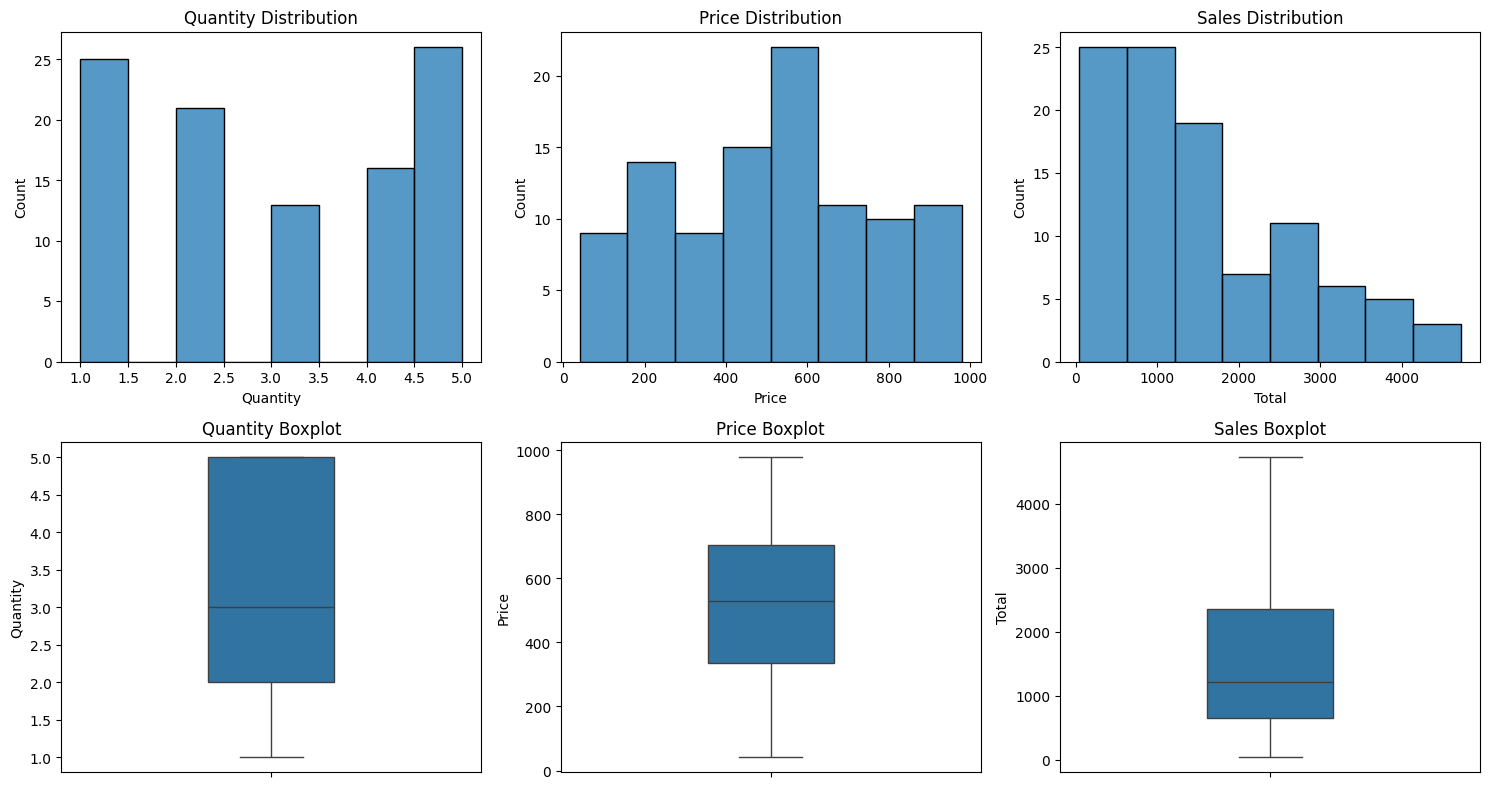

In [ ]:
from numpy import outer
#Quantity, price and sales distribution
fig, ax = plt.subplots(2, 3, figsize=(15, 8)) #set the canva nad the division for each graph

#Quantity distribution
sns.histplot(df['Quantity'],ax=ax[0,0])
ax[0,0].set_title('Quantity Distribution')
sns.boxplot(df['Quantity'],ax=ax[1,0], width = 0.3)
ax[1,0].set_title('Quantity Boxplot')

#Price distribution
sns.histplot(df['Price'],ax=ax[0,1])
ax[0,1].set_title('Price Distribution')
sns.boxplot(df['Price'],ax=ax[1,1], width = 0.3)
ax[1,1].set_title('Price Boxplot')

#Sales distribution
sns.histplot(df['Total'],ax=ax[0,2])
ax[0,2].set_title('Sales Distribution')
sns.boxplot(df['Total'],ax=ax[1,2], width = 0.3)
ax[1,2].set_title('Sales Boxplot')

#Tight the layout
plt.tight_layout()
plt.show()


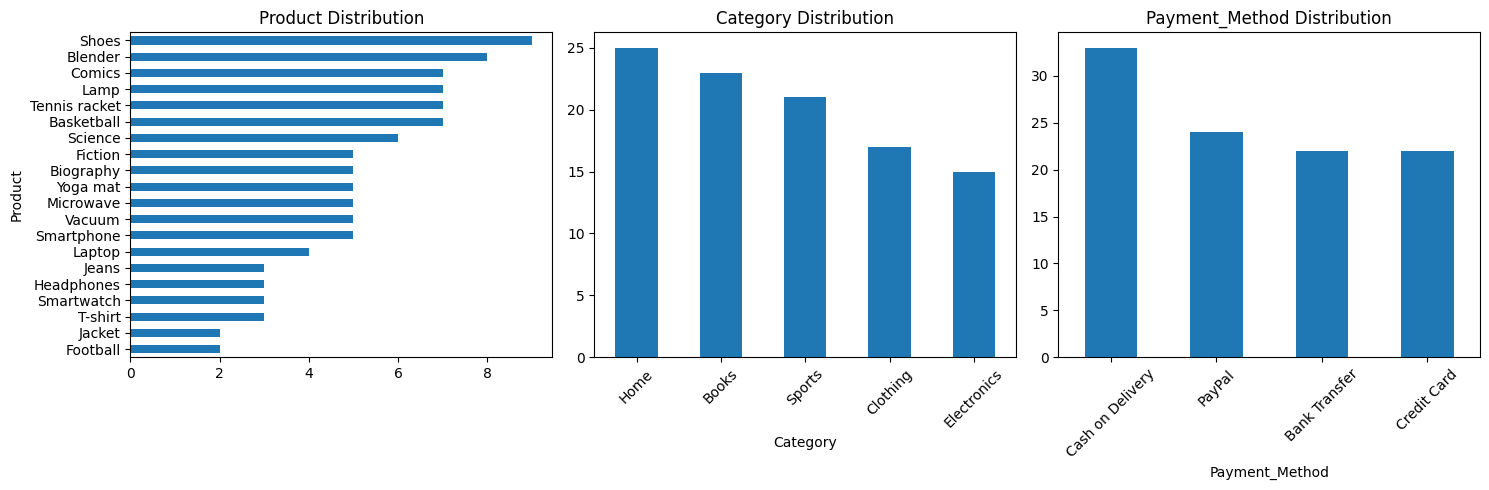

In [ ]:
#Categorical variables
fig2, ax2 = plt.subplots(1, 3, figsize=(15,5))

#Product distribution
products = df['Product'].value_counts()
products = products.sort_values(ascending = True)
products.plot(kind='barh', ax=ax2[0] )
ax2[0].set_title('Product Distribution')

#Category distribution
df['Category'].value_counts().plot(kind='bar', ax=ax2[1])
ax2[1].set_title('Category Distribution')
ax2[1].xaxis.set_tick_params(rotation=45)

#Payment_Method distribution
df['Payment_Method'].value_counts().plot(kind='bar', ax=ax2[2])
ax2[2].set_title('Payment_Method Distribution')
ax2[2].xaxis.set_tick_params(rotation=45)

#Tight the axes
plt.tight_layout()
plt.show()

**Binary Analysis**

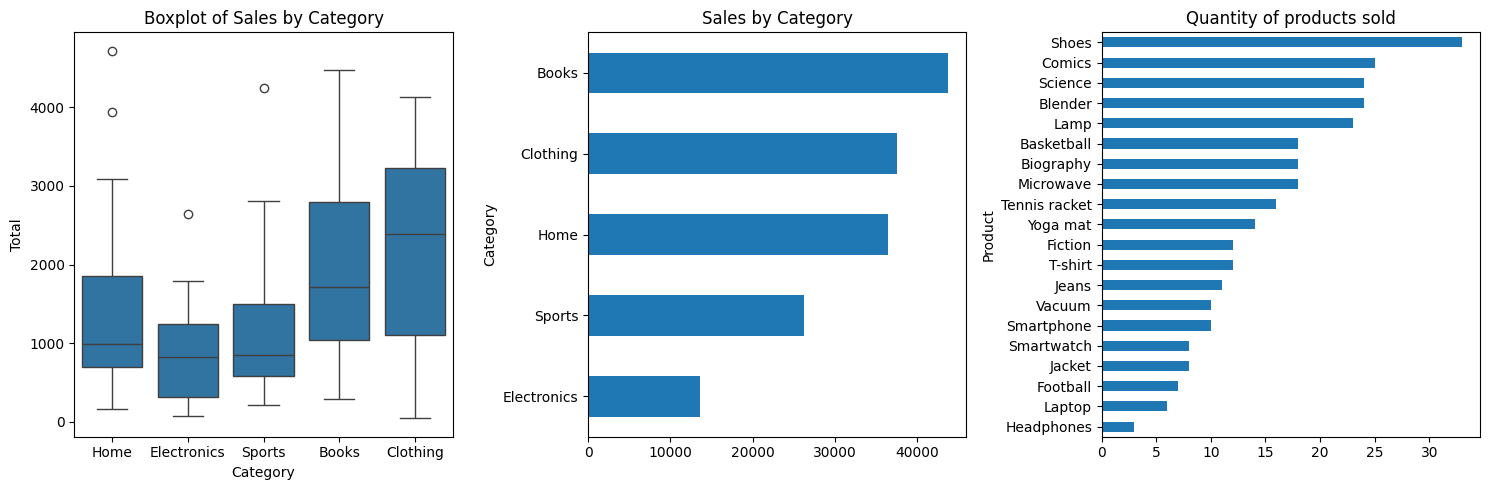

In [ ]:
#Create the figure
fig3, ax3 = plt.subplots(1, 3, figsize=(15,5))

#Sales by category
sns.boxplot(data = df, x = 'Category', y = 'Total', ax = ax3[0])
ax3[0].set_title('Boxplot of Sales by Category')

sales_by_category = df.groupby('Category')['Total'].sum()
sales_by_category = sales_by_category.sort_values(ascending = True)
sales_by_category.plot(kind='barh', ax = ax3[1])
ax3[1].set_title('Sales by Category')

#Product most sold
sales_by_product = df.groupby('Product')['Quantity'].sum()
sales_by_product = sales_by_product.sort_values(ascending = True)
sales_by_product.plot(kind='barh', ax = ax3[2])
ax3[2].set_title('Quantity of products sold')

#tight layout
plt.tight_layout()
plt.show()

**Time series**

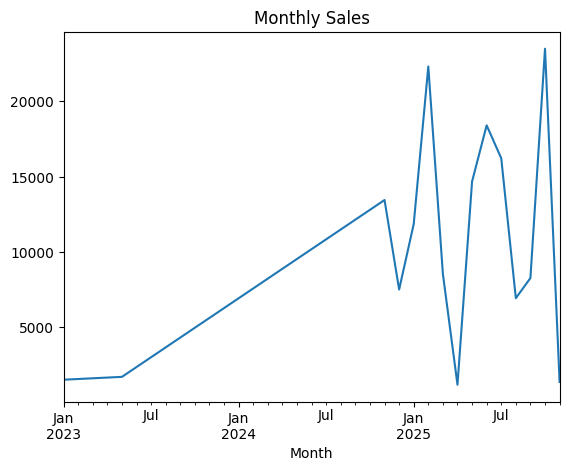

In [ ]:
#Turn the date column into datetime
#df['Order_Date'] = pd.to_datetime(df['Order_Date'])

#Create a column month period
df['Month'] = df['Order_Date'].dt.to_period('M')
monthly_sales = df.groupby('Month')['Total'].sum()
monthly_sales.plot()
plt.title('Monthly Sales')
plt.show()

**Key Insights**

- The Home category is the most popular, while shoes and blender are the most popular products.
- The most popular payment method among customers is cash on delivery.
- Book category products generates the highest revenue, while electronics category represent a marginal proportion.
- Regarding the product, shoes generates the highest revenue.
- In 2024, the sales grew steadily. However, in 2025, sales fluctuated dramatically reaching their peack in October.
